In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from trees.causal_forest import CF


N = 10000
default_K = 5
default_w = 0.6
iterations = 30
MIN_S = 0.3
MAX_S = 0.95
ws = [0.0, 0.2,  0.4,  0.6, 0.8,  1.0]
Ks = [1, 3, 5, 7, 10]

cols = ['condition', 't', 't_est', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score', 'true_score', 'algorithm', 'weight']

scores_over_K = pd.DataFrame(columns=cols)
scores_over_w = pd.DataFrame(columns=cols)


for exp in tqdm(range(iterations)):
    data = Data()
    data.generate(n=N, seed=exp)
    data.generate_random_condition(min_s=MIN_S, max_s=MAX_S)

    ct_D = CT(data, on = "D")
    ct_D.fit(max_depth=6)
    ct_D.parse_tree()

    ct_P = CT(data, on = "P")
    ct_P.fit(max_depth=6)
    ct_P.parse_tree()

    cf_mse = CF(data)
    cf_mse.fit(criterion="mse", n_estimators=100, max_depth=4)
    cf_mse.parse_forest()  

    # cf_mse_tuned = CF(data)
    # cf_mse_tuned.fit(criterion="mse", n_estimators=100, tune=True)
    # cf_mse_tuned.parse_forest()     

    # cf_het = CF(data)
    # cf_het.fit(criterion="het", n_estimators=100)
    # cf_het.parse_forest()   

    # cf_het_tuned = CF(data)
    # cf_het_tuned.fit(criterion="het", n_estimators=100, tune=True)
    # cf_het_tuned.parse_forest()   

    for w in ws:
        # for alg in [ct_D, ct_P, cf_mse, cf_het, cf_mse_tuned, cf_het_tuned]:
        for alg in [ct_D, ct_P, cf_mse]:
            score = alg.get_topK(k=default_K, w=w, print_summaries=False)
            score['weight'] = w
            scores_over_w=pd.concat([scores_over_w, score], ignore_index=True)
    
    for K in Ks:
        # for alg in [ct_D, ct_P, cf_mse, cf_het]:
        for alg in [ct_D, ct_P, cf_mse]:
            score = alg.get_topK(k=K, w=default_w, print_summaries=False)
            score['K'] = K
            scores_over_K=pd.concat([scores_over_K, score], ignore_index=True)

    for alg in [cf_mse]:
    # for alg in [cf_mse, cf_het, cf_mse_tuned, cf_het_tuned]:
        alg.single_tree_interpreter(max_depth=10)
    
   
    for w in ws:
        for alg in [cf_mse]:
        # for alg in [cf_mse, cf_het, cf_mse_tuned, cf_het_tuned]:
            score = alg.get_topK(k=default_K, w=w, print_summaries=False)
            score['weight'] = w
            scores_over_w=pd.concat([scores_over_w, score], ignore_index=True)

    for K in Ks:
        for alg in [cf_mse]:
        # for alg in [cf_mse, cf_het, cf_mse_tuned, cf_het_tuned]:
            score = alg.get_topK(k=K, w=default_w, print_summaries=False)
            score['K'] = K
            scores_over_K=pd.concat([scores_over_K, score], ignore_index=True)

100%|██████████| 30/30 [12:24<00:00, 24.81s/it]


# Experiments with different weights

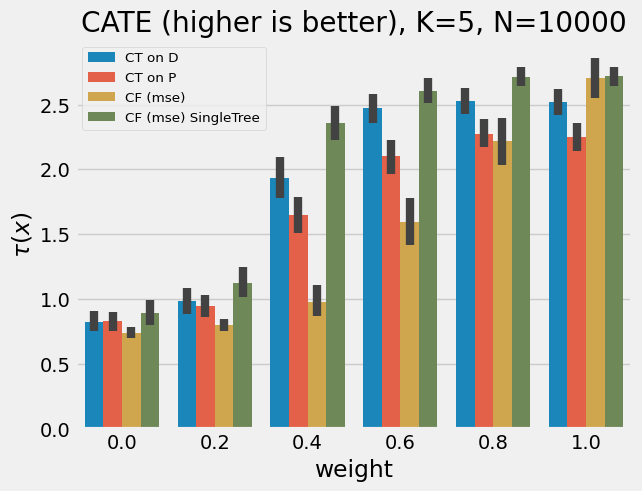

In [2]:
sns.barplot(x='weight', y='t', hue='algorithm', data=scores_over_w)
plt.title(f"CATE (higher is better), K={str(default_K)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.legend(fontsize='x-small')
plt.show()

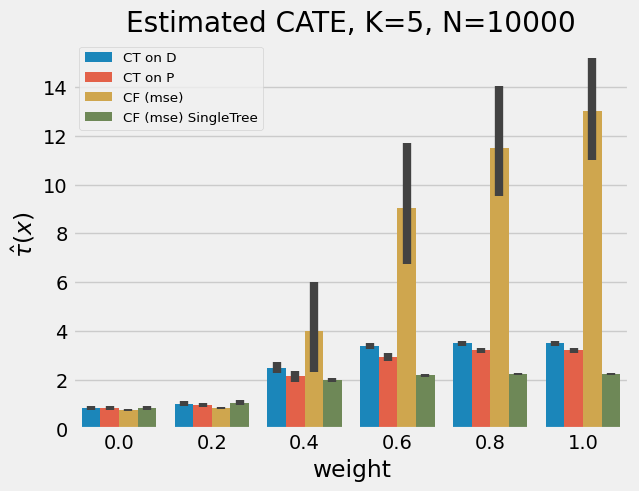

In [3]:
sns.barplot(x='weight', y='t_est', hue='algorithm', data=scores_over_w)
plt.title(fr"Estimated CATE, K={str(default_K)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.legend(fontsize='x-small')
plt.show()

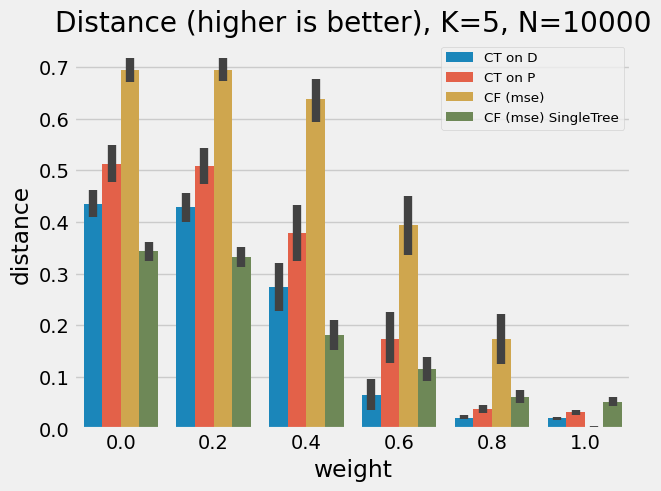

In [4]:
sns.barplot(x='weight', y='distance', hue='algorithm', data=scores_over_w)
plt.title(f"Distance (higher is better), K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

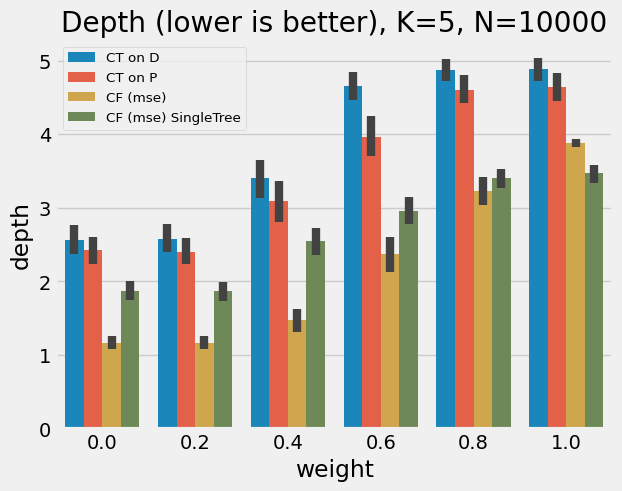

In [5]:
sns.barplot(x='weight', y='depth', hue="algorithm", data=scores_over_w)
plt.title(f"Depth (lower is better), K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

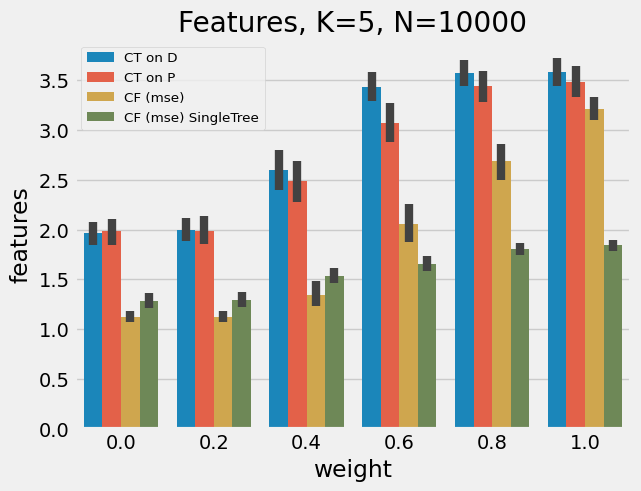

In [20]:
sns.barplot(x='weight', y='features', hue="algorithm", data=scores_over_w)
plt.title(f"Features, K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

In [7]:
scores_over_w

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,true_score,algorithm,weight,features,execution_time
0,feature_2 > -1.159,0.796,0.873,0.94,0.977846,1.850938,1,0.176150,0.940000,0.940000,CT on D,0.0,1.0,NaN
1,feature_2 > -1.159 AND feature_0 > -0.089,1.541,1.659,0.51,0.846389,2.504945,2,0.334746,0.510000,0.510000,CT on D,0.0,2.0,NaN
2,feature_2 > -1.159 AND feature_0 <= -0.089,0.048,0.018,0.45,1.126951,1.109136,2,0.003632,0.450000,0.450000,CT on D,0.0,2.0,NaN
3,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,1.158,1.268,0.33,0.771158,2.038845,3,0.255851,0.330000,0.330000,CT on D,0.0,2.0,NaN
4,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,1.048,1.162,0.30,0.671156,1.833117,4,0.234463,0.300000,0.300000,CT on D,0.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,3.795,2.394,0.01,NaN,NaN,4,1.000000,1.000000,1.000000,CF (mse) SingleTree,1.0,2.0,11.9
3596,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,3.029,2.222,0.02,NaN,NaN,4,0.928154,0.928154,0.798155,CF (mse) SingleTree,1.0,2.0,11.9
3597,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,2.839,2.095,0.06,NaN,NaN,3,0.875104,0.875104,0.748090,CF (mse) SingleTree,1.0,1.0,11.9
3598,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,2.650,2.035,0.05,NaN,NaN,4,0.850042,0.850042,0.698287,CF (mse) SingleTree,1.0,2.0,11.9


In [8]:
import pickle as pkl

with open("scores_over_w_new.pkl", "wb") as f:
    pkl.dump(scores_over_w, f)

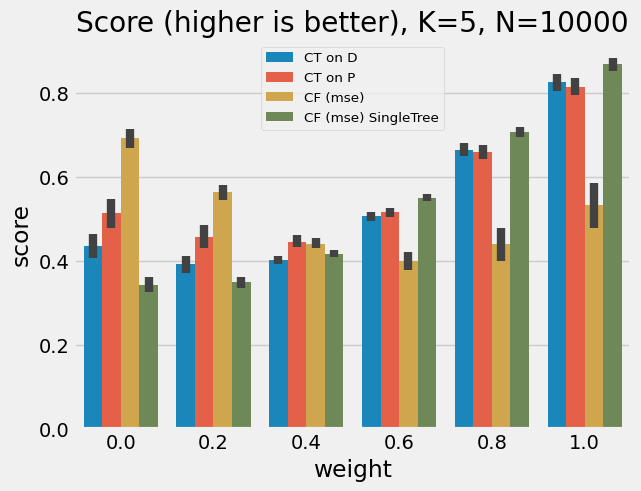

In [9]:
sns.barplot(x='weight', y='score', hue='algorithm', data=scores_over_w)
plt.title(f"Score (higher is better), K={str(default_K)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

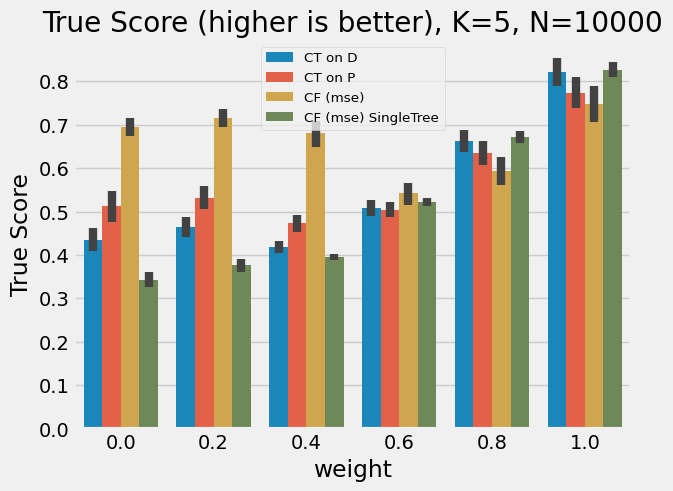

In [10]:
sns.barplot(x='weight', y='true_score', hue='algorithm', data=scores_over_w)
plt.title(f"True Score (higher is better), K={str(default_K)}, N={str(N)}")
plt.ylabel("True Score")
plt.legend(fontsize='x-small')
plt.show()

# Experiments with different K

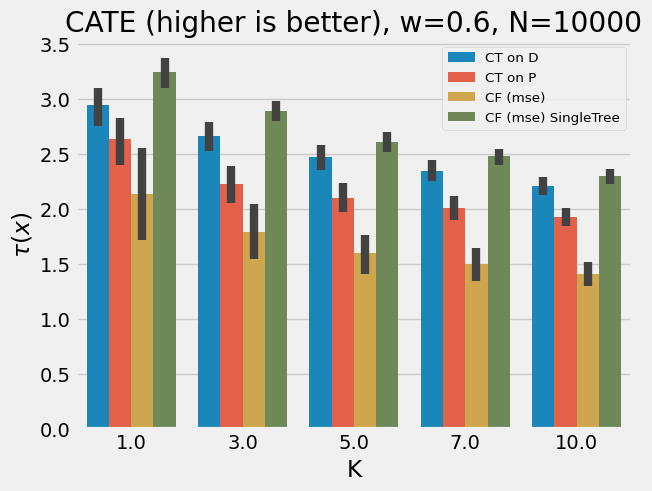

In [11]:
sns.barplot(x='K', y='t', hue='algorithm', data=scores_over_K)
plt.title(f"CATE (higher is better), w={str(default_w)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.legend(fontsize='x-small')
plt.show()

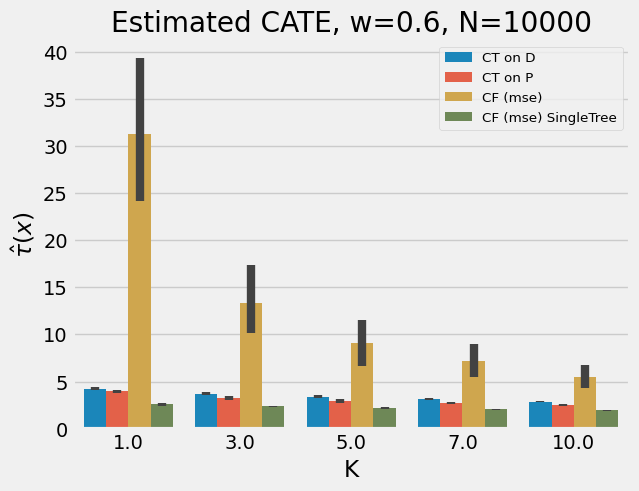

In [12]:
sns.barplot(x='K', y='t_est', hue='algorithm', data=scores_over_K)
plt.title(fr"Estimated CATE, w={str(default_w)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.legend(fontsize='x-small')
plt.show()

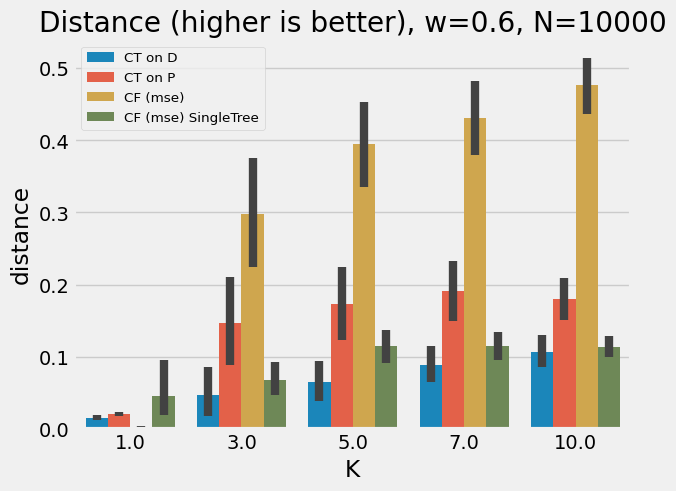

In [13]:
sns.barplot(x='K', y='distance', hue='algorithm', data=scores_over_K)
plt.title(f"Distance (higher is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

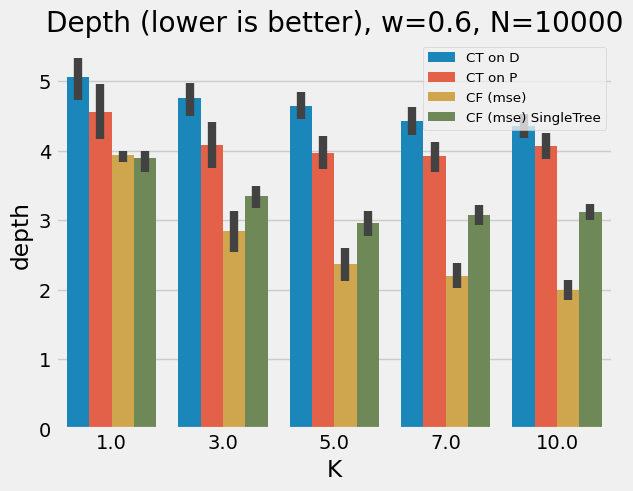

In [14]:
sns.barplot(x='K', y='depth', hue="algorithm", data=scores_over_K)
plt.title(f"Depth (lower is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

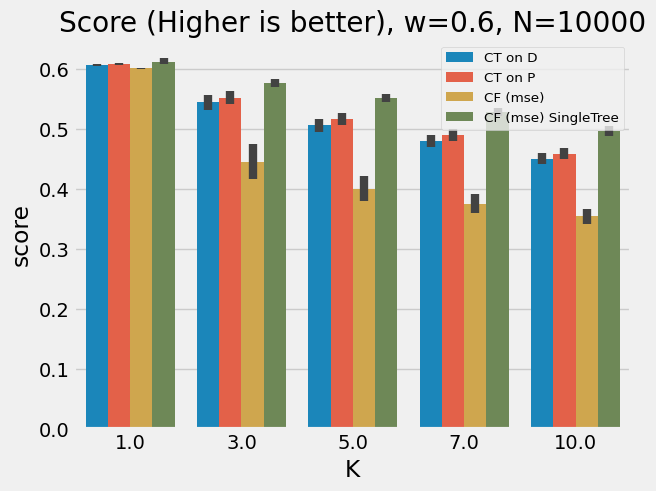

In [15]:
sns.barplot(x='K', y='score', hue="algorithm", data=scores_over_K)
plt.title(f"Score (Higher is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

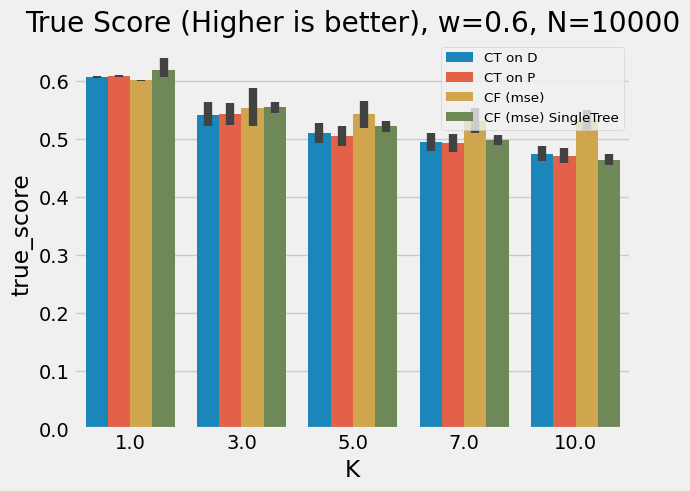

In [16]:
sns.barplot(x='K', y='true_score', hue="algorithm", data=scores_over_K)
plt.title(f"True Score (Higher is better), w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

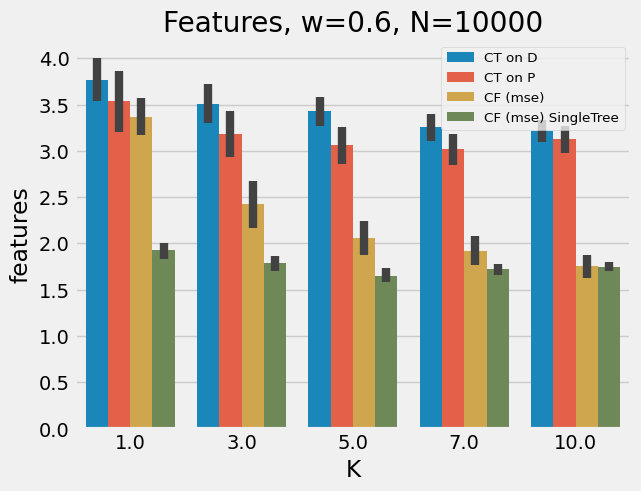

In [17]:
sns.barplot(x='K', y='features', hue="algorithm", data=scores_over_K)
plt.title(f"Features, w={str(default_w)}, N={str(N)}")
plt.legend(fontsize='x-small')
plt.show()

In [18]:
scores_over_K

,condition,t,t_est,distance,T0,T1,depth,norm_cate,score,true_score,algorithm,weight,features,K,execution_time
0,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,2.654,4.956,0.01,-0.037235,4.918357,6,1.000000,0.604000,0.604000,CT on D,NaN,4.0,1.0,NaN
1,feature_0 <= 2.171 AND feature_0 > 0.002 AND f...,2.885,3.913,0.02,1.074259,4.986802,6,1.000000,0.608000,0.608000,CT on P,NaN,3.0,1.0,NaN
2,feature_0 <= -0.02 AND feature_1 > 1.647 AND f...,1.479,20.290,0.00,NaN,NaN,4,1.000000,0.600000,0.600000,CF (mse),NaN,4.0,1.0,5.79
3,feature_2 > -1.159 AND feature_0 > -0.089 AND ...,2.654,4.956,0.01,-0.037235,4.918357,6,1.000000,0.604000,0.604000,CT on D,NaN,4.0,3.0,NaN
4,feature_2 > -1.159,0.796,0.873,0.94,0.977846,1.850938,1,0.176150,0.481690,0.555955,CT on D,NaN,1.0,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3115,feature_0 > -0.201,1.511,1.243,0.47,NaN,NaN,1,0.519215,0.499529,0.426893,CF (mse) SingleTree,NaN,1.0,10.0,11.90
3116,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,2.048,1.705,0.10,NaN,NaN,3,0.712197,0.467318,0.363794,CF (mse) SingleTree,NaN,1.0,10.0,11.90
3117,feature_0 > -0.201 AND feature_0 > 0.959 AND f...,1.884,1.618,0.09,NaN,NaN,4,0.675856,0.441514,0.333866,CF (mse) SingleTree,NaN,2.0,10.0,11.90
3118,feature_0 > -0.201 AND feature_0 <= 0.959 AND ...,2.442,1.679,0.02,NaN,NaN,4,0.701337,0.428802,0.394087,CF (mse) SingleTree,NaN,2.0,10.0,11.90


In [19]:
with open("scores_over_K_new.pkl", "wb") as f:
    pkl.dump(scores_over_K, f)